# Docker Stall / Timeout Analysis — Runs 6.1 & 6.2

Source: `metrics/stalled_tasks_union_6.1_6.2.csv` — every task whose Docker container failed to come up (`docker compose up ... --wait` timed out) at least once in either GRPO run.

- **6.1** = `20260827_v1v2v3hard_phase2` (log covers steps **61+**, a resume log)
- **6.2** = `20260922_v1v2v3hard_phase2_stratified` (log covers steps **41+**, a resume log)
- Same ~6,000-task dataset (v1+v2+v3hard); 6.1 = global combine, 6.2 = per-category stratified split.

**A stall is an infrastructure failure, not a model failure** — the task never ran, so it is retried then loss-masked (excluded from training and from pass@2).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette (validated: dataviz skill, light surface)
C_DATASET = {
    'harbor_tasks_v3hard':      '#2a78d6',  # blue
    'harbor_tasks_8192_deduped':'#eb6834',  # orange
    'harbor_tasks_457':         '#1baf7a',  # aqua
}
# Difficulty is ordinal -> sequential single-hue blue ramp (light->dark)
C_DIFF = {'easy': '#86b6ef', 'medium': '#3987e5', 'hard': '#1c5cab', 'NOT_FOUND': '#c9c7c1'}
INK, MUTED = '#0b0b0b', '#898781'

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': '#e6e5e1', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
})

df = pd.read_csv('metrics/stalled_tasks_union_6.1_6.2.csv')
print('Unique stalled tasks:', len(df))
df.head()

Unique stalled tasks: 249


,task_id,dataset,difficulty,category,build_timeout_sec,stall_events_6.1,stall_events_6.2,stall_events_total
0,task_000000_3dae2e11,harbor_tasks_457,NOT_FOUND,NOT_FOUND,NaN,0,20,20
1,task_004547_8bd58040,harbor_tasks_8192_deduped,easy,service configuration,600.0,0,20,20
2,task_002413_62ccc87d,harbor_tasks_8192_deduped,medium,environment variable and dotenv management,600.0,10,4,14
3,task_000000_a11c4531,harbor_tasks_457,NOT_FOUND,NOT_FOUND,NaN,0,10,10
4,task_000000_fddbe5e3,harbor_tasks_457,NOT_FOUND,NOT_FOUND,NaN,10,0,10


In [2]:
# Overlap between the two runs — the key headline
in61 = df['stall_events_6.1'] > 0
in62 = df['stall_events_6.2'] > 0
both   = int((in61 & in62).sum())
only61 = int((in61 & ~in62).sum())
only62 = int((~in61 & in62).sum())
print(f'Stalled in BOTH runs : {both}')
print(f'Only 6.1             : {only61}')
print(f'Only 6.2             : {only62}')
print()
print('Total stall EVENTS   6.1:', int(df["stall_events_6.1"].sum()),
      ' 6.2:', int(df["stall_events_6.2"].sum()))

Stalled in BOTH runs : 4
Only 6.1             : 123
Only 6.2             : 122

Total stall EVENTS   6.1: 598  6.2: 624


> **Caveat — read before interpreting overlap.** Each run only *samples* a slice of the dataset: batch size 8 x ~150 logged steps ~ ~1,000 distinct tasks tried, out of ~6,000. Neither run finished its planned steps (6.1 was set for 816). So the near-zero overlap mostly reflects the two runs trying **different** tasks, **not** proof that stalls are random. To separate broken-vs-flaky you'd need the *attempted*-task lists and check re-stall rate on the intersection.

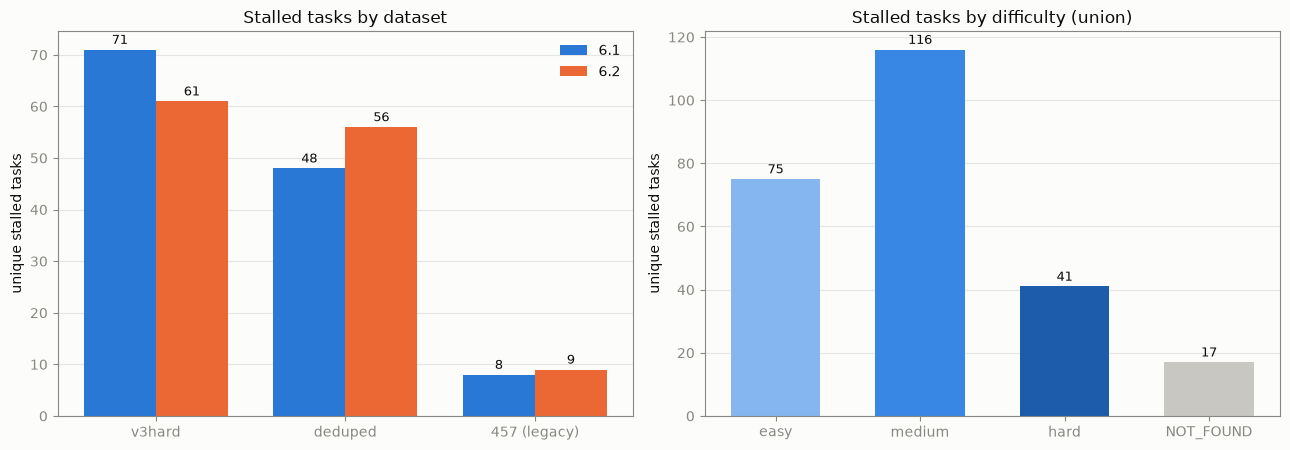

In [3]:
# Panel 1: unique stalled tasks by dataset (grouped by which run) + by difficulty
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ds_order = ['harbor_tasks_v3hard', 'harbor_tasks_8192_deduped', 'harbor_tasks_457']
labels = ['v3hard', 'deduped', '457 (legacy)']
c61 = [int(((df['dataset']==d) & in61).sum()) for d in ds_order]
c62 = [int(((df['dataset']==d) & in62).sum()) for d in ds_order]
x = np.arange(len(ds_order)); w = 0.38
b1 = ax.bar(x-w/2, c61, w, label='6.1', color='#2a78d6')
b2 = ax.bar(x+w/2, c62, w, label='6.2', color='#eb6834')
ax.bar_label(b1, padding=2, color=INK, fontsize=9)
ax.bar_label(b2, padding=2, color=INK, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('unique stalled tasks'); ax.set_title('Stalled tasks by dataset')
ax.legend(frameon=False); ax.grid(axis='x', visible=False)

ax = axes[1]
diff_order = ['easy', 'medium', 'hard', 'NOT_FOUND']
counts = [int((df['difficulty']==d).sum()) for d in diff_order]
bars = ax.bar(diff_order, counts, color=[C_DIFF[d] for d in diff_order], width=0.62)
ax.bar_label(bars, padding=2, color=INK, fontsize=9)
ax.set_ylabel('unique stalled tasks'); ax.set_title('Stalled tasks by difficulty (union)')
ax.grid(axis='x', visible=False)

plt.tight_layout(); plt.savefig('metrics/docker_stall_by_dataset_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()

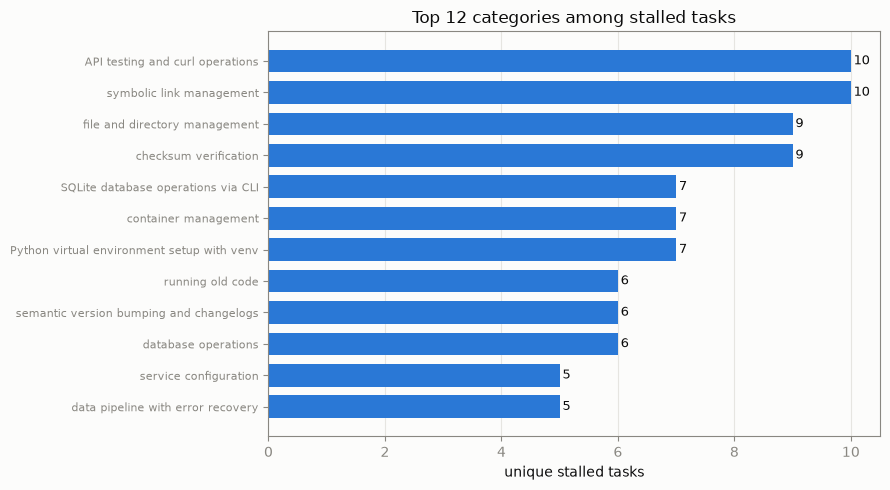

Distinct categories among stalled tasks: 61
Max share by any single category: 10/249 = 4.0%


In [5]:
# Category spread — is any topic over-represented?
cat = df[df['category'] != 'NOT_FOUND']['category'].value_counts().head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(np.arange(len(cat)), cat.values, color='#2a78d6', height=0.72)
ax.set_yticks(np.arange(len(cat))); ax.set_yticklabels(cat.index, fontsize=8)
ax.bar_label(bars, padding=2, color=INK, fontsize=9)
ax.set_xlabel('unique stalled tasks'); ax.set_title('Top 12 categories among stalled tasks')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.savefig('metrics/docker_stall_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Distinct categories among stalled tasks: {df[df['category']!='NOT_FOUND']['category'].nunique()}")
print('Max share by any single category:', f"{cat.max()}/{len(df)} = {cat.max()/len(df):.1%}")

## Category word cloud

Each category sized by its **total stall events** across both runs (retries counted, same weight as the top-repeat-stallers panel). Whole category names are kept intact — this is the same signal as the bar chart above, read at a glance. `NOT_FOUND` (the legacy 457 tasks with no `task.toml`) is excluded.

In [ ]:
# Word cloud of stalled-task categories, size ∝ total stall events (retries counted)
# Needs `wordcloud`: pip install wordcloud
from wordcloud import WordCloud

freq = (df[df['category'] != 'NOT_FOUND']
        .groupby('category')['stall_events_total'].sum()
        .astype(float).to_dict())

# Colour each category from the validated palette (deterministic per word)
_cloud_cols = ['#2a78d6', '#eb6834', '#1baf7a', '#1c5cab']
def _color(word, **kwargs):
    return _cloud_cols[sum(map(ord, word)) % len(_cloud_cols)]

wc = WordCloud(width=1100, height=500, background_color='#fcfcfb',
               prefer_horizontal=0.9, color_func=_color,
               collocations=False, relative_scaling=0.5
               ).generate_from_frequencies(freq)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Stalled-task categories (size ∝ total stall events)', color=INK)
plt.tight_layout()
plt.savefig('metrics/docker_stall_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 categories by stall weight, for the record
print(pd.Series(freq).sort_values(ascending=False).head(10).astype(int))

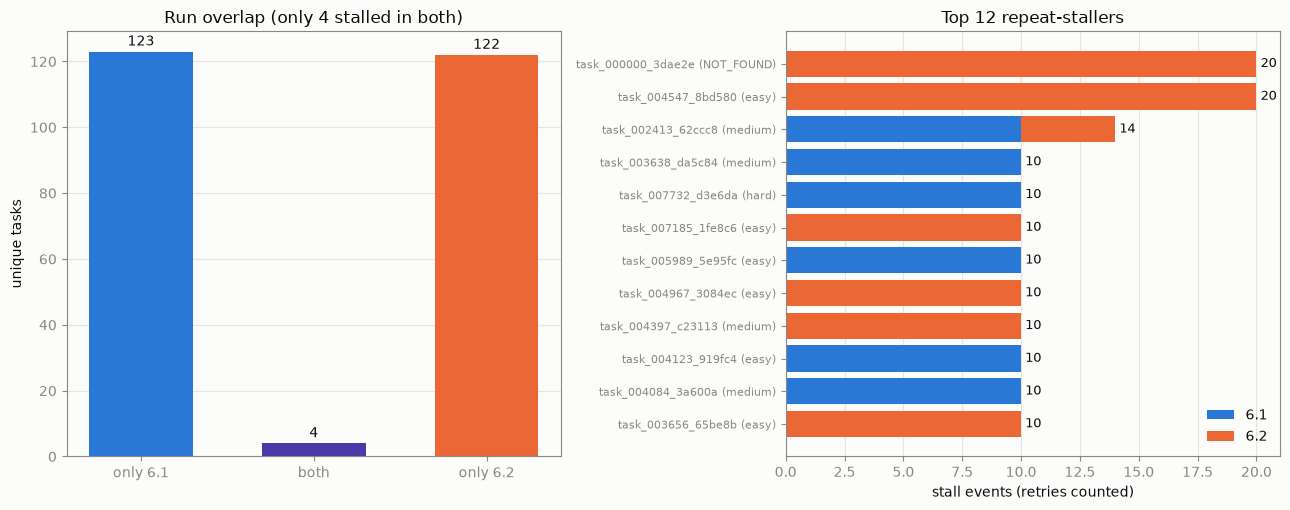

In [4]:
# Panel 2: run overlap + top repeat-stallers (the genuinely suspect tasks)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
seg = ['only 6.1', 'both', 'only 6.2']
vals = [only61, both, only62]
cols = ['#2a78d6', '#4a3aa7', '#eb6834']
bars = ax.bar(seg, vals, color=cols, width=0.6)
ax.bar_label(bars, padding=2, color=INK, fontsize=10)
ax.set_ylabel('unique tasks'); ax.set_title(f'Run overlap (only {both} stalled in both)')
ax.grid(axis='x', visible=False)

ax = axes[1]
top = df.sort_values('stall_events_total', ascending=False).head(12).iloc[::-1]
y = np.arange(len(top))
b1 = ax.barh(y, top['stall_events_6.1'], color='#2a78d6', label='6.1')
b2 = ax.barh(y, top['stall_events_6.2'], left=top['stall_events_6.1'], color='#eb6834', label='6.2')
ax.set_yticks(y)
ax.set_yticklabels([f"{t[:18]} ({d})" for t, d in zip(top['task_id'], top['difficulty'])], fontsize=8)
ax.bar_label(b2, labels=[str(int(v)) for v in top['stall_events_total']], padding=3, color=INK, fontsize=9)
ax.set_xlabel('stall events (retries counted)'); ax.set_title('Top 12 repeat-stallers')
ax.legend(frameon=False, loc='lower right'); ax.grid(axis='y', visible=False)

plt.tight_layout(); plt.savefig('metrics/docker_stall_overlap_top.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Chronic repeat-stallers = the only tasks worth excluding from training data
REPEAT_THRESHOLD = 6  # stalled >= this many times within a single run
chronic = df[(df['stall_events_6.1'] >= REPEAT_THRESHOLD) | (df['stall_events_6.2'] >= REPEAT_THRESHOLD)]
chronic = chronic.sort_values('stall_events_total', ascending=False)
print(f'Chronic repeat-stallers (>= {REPEAT_THRESHOLD}x in one run): {len(chronic)} tasks')
chronic.to_csv('metrics/chronic_stallers_exclude_list.csv', index=False)
print('Saved -> metrics/chronic_stallers_exclude_list.csv')
chronic[['task_id','dataset','difficulty','category','stall_events_6.1','stall_events_6.2']]

Chronic repeat-stallers (>= 6x in one run): 46 tasks
Saved -> metrics/chronic_stallers_exclude_list.csv


,task_id,dataset,difficulty,category,stall_events_6.1,stall_events_6.2
0,task_000000_3dae2e11,harbor_tasks_457,NOT_FOUND,NOT_FOUND,0,20
1,task_004547_8bd58040,harbor_tasks_8192_deduped,easy,service configuration,0,20
2,task_002413_62ccc87d,harbor_tasks_8192_deduped,medium,environment variable and dotenv management,10,4
13,task_003638_da5c84bd,harbor_tasks_v3hard,medium,SQLite database operations via CLI,10,0
22,task_007185_1fe8c647,harbor_tasks_v3hard,easy,Makefile authoring and task automation,0,10
21,task_005989_5e95fcf5,harbor_tasks_v3hard,easy,checksum verification,10,0
20,task_004967_3084ec3c,harbor_tasks_v3hard,easy,optimization solvers,0,10
19,task_004579_dca8e529,harbor_tasks_8192_deduped,easy,log analysis,0,10
18,task_004397_c2311391,harbor_tasks_8192_deduped,medium,scheduled tasks and cron jobs,0,10
17,task_004123_919fc4fc,harbor_tasks_8192_deduped,easy,container management,10,0


## Findings

1. **Stalls are infrastructure, not task quality.** They hit all difficulties (easy/medium/hard) and spread across ~40 categories with no single topic dominant. A task marked *easy* stalled 20x.
2. **The build timeout is already 600s.** The 300s to raise is a *different* limit — the agent/verifier `timeout_sec` or the docker-compose `--wait`, not `build_timeout_sec`.
3. **Only a handful of tasks stalled in both runs**, but this is *not* proof of randomness — both runs stopped early and sampled mostly different tasks (~1,000 of ~6,000 each).
4. **Actionable:** exclude only the chronic repeat-stallers (`chronic_stallers_exclude_list.csv`); the rest is timeout flakiness that a higher agent/compose timeout would fix. Real broken-vs-flaky separation needs per-step *attempted*-task logging (tickets #68/#69).